In [47]:
import pandas as pd

df = pd.read_csv("../../data/stock_advice.csv")

<Axes: xlabel='Advisor Name'>

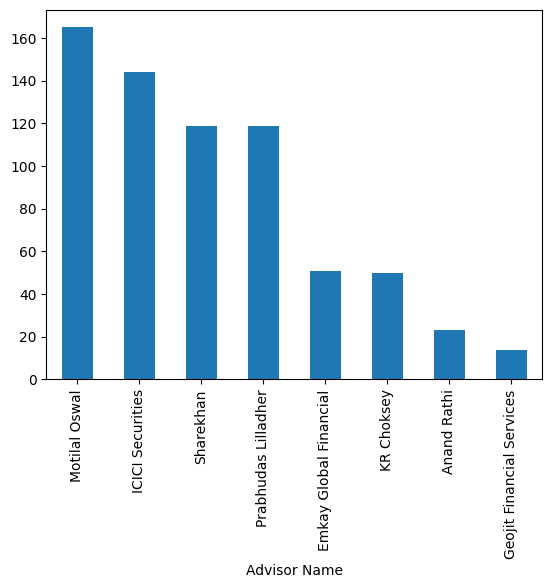

In [56]:
def clean_advisor_name(name):
    if "Prabhudas Lilladher" in name:
        return "Prabhudas Lilladher"
    return name
df["Advisor Name"] = df["Advisor Name"].apply(clean_advisor_name)

# df.groupby("Advisor Name")
advisor_value_counts = df["Advisor Name"].value_counts()#.plot(kind="bar")
filtered_df = df[df["Advisor Name"].isin(advisor_value_counts[advisor_value_counts > 10].index)]
filtered_df = filtered_df[(filtered_df["Arbitrage %"] < 200) & (filtered_df["Arbitrage %"] > 0)]
filtered_df["Advisor Name"].value_counts().plot(kind="bar")

In [57]:
len(filtered_df)

685

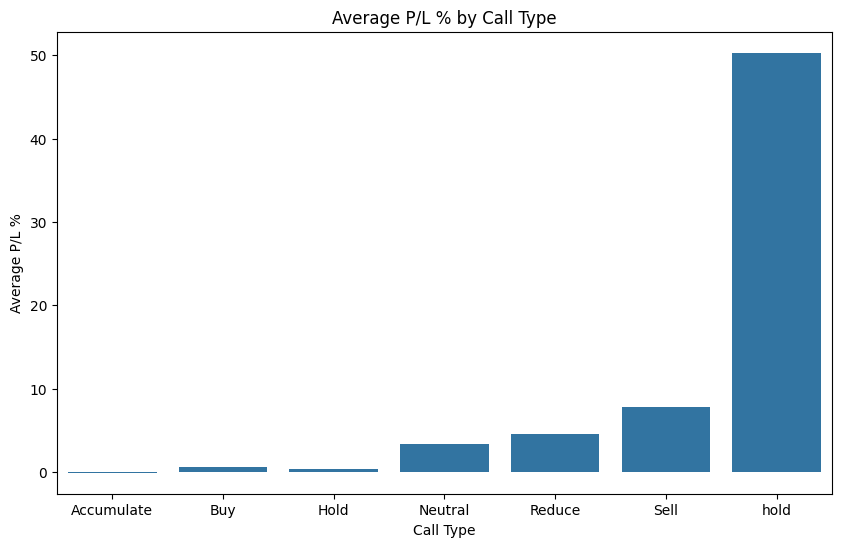

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the success rate of each call type
call_success = filtered_df.groupby('Call')["Today P/L %"].mean().reset_index()
call_success.columns = ['Call', 'Average P/L %']

# Plot the success rate of each call type
plt.figure(figsize=(10, 6))
sns.barplot(x='Call', y='Average P/L %', data=call_success)
plt.title('Average P/L % by Call Type')
plt.xlabel('Call Type')
plt.ylabel('Average P/L %')
plt.show()


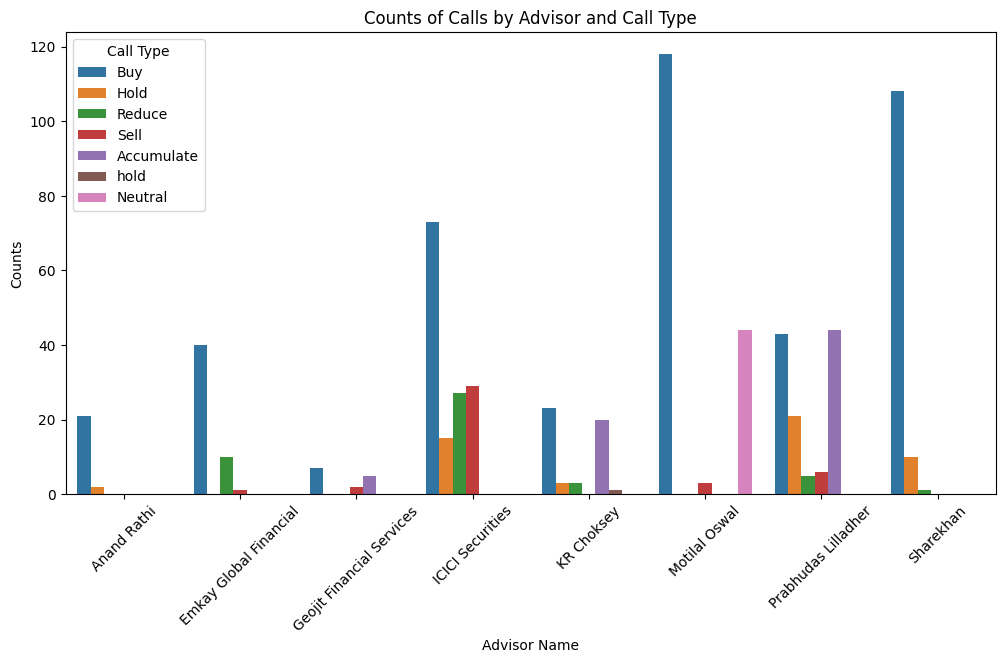

In [59]:
grouped_counts = filtered_df.groupby(['Advisor Name', 'Call']).size().reset_index(name='Counts')
plt.figure(figsize=(12, 6))
sns.barplot(x='Advisor Name', y='Counts', hue='Call', data=grouped_counts)
plt.title('Counts of Calls by Advisor and Call Type')
plt.xlabel('Advisor Name')
plt.ylabel('Counts')
plt.legend(title='Call Type')
plt.xticks(rotation=45)
plt.show()

Not reached yet.            466.000000
Call type not supported.     90.000000
Average                      51.852713
Total                       129.000000
Max                         121.000000
Min                           1.000000
dtype: float64



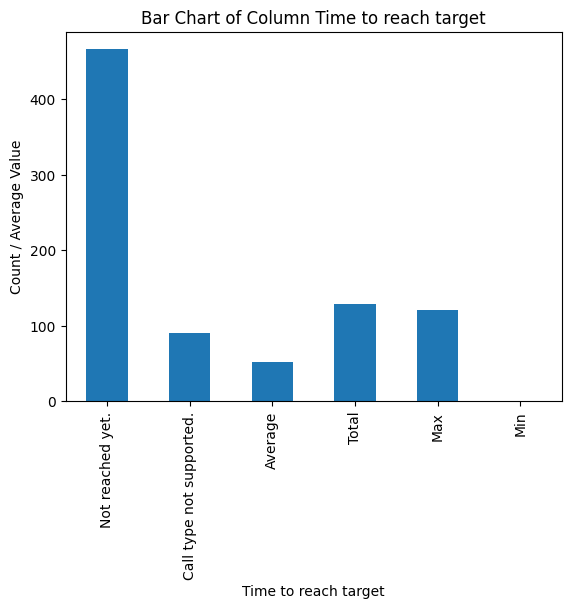

In [64]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_mixed_column(df, column):
    # Separate strings and numeric values
    strings = df[df[column].apply(lambda x: isinstance(x, str) and not x.isdigit())]
    def convert_to_float(x):
        try:
            return float(x)
        except ValueError:
            return x
    numerics = df[df[column].apply(lambda x: isinstance(x, (int, float))or (isinstance(x, str) and x.isdigit()))]

    # Count the strings
    string_counts = strings[column].value_counts()

    # Calculate the average of numeric values
    if numerics.empty:
        return
    
    numerics = numerics[column].apply(convert_to_float)

    combined_data = pd.concat([string_counts, pd.Series({
        'Average': numerics.mean(),
        "Total":len(numerics),
        "Max": numerics.max(),
        "Min": numerics.min()
    })], axis=0)

    print(combined_data)
    print()
    # Plot the combined data
    combined_data.plot(kind='bar')
    plt.title(f'Bar Chart of Column {column}')
    plt.ylabel('Count / Average Value')
    plt.xlabel(column)
    plt.show()

# Example usage
plot_mixed_column(filtered_df, 'Time to reach target')


In [54]:
df[df["Time to reach target"].astype(str).str.isdigit()]
df.head()
# df[df["Time to reach target"] == "Call type not supported."]
# df[df["Arbitrage %"]>50].sort_values(by="Article Date", ascending=False)
# df.sort_values(by="Article Date", ascending=False)
# df.groupby("Advisor Name").agg({"Today P/L %": ["mean", "std", "count"]}).sort_values(by=("Today P/L %", "count"), ascending=False)

,Article Date,Advisor Name,Stock Name,Company Code,Call,Price on Article Day,Target Price,Today's Price,Time to reach target,Arbitrage %,Today P/L %,Article URL
0,2024-06-18 14:15:00,Prabhudas Lilladher,Mahindra and Mahindra,M&M,Buy,2857.45,3250,2720.85,Not reached yet.,55.454045,30.143735,https://www.moneycontrol.com/news/business/sto...
1,2024-06-18 14:23:00,Prabhudas Lilladher,Praj Industries,PRAJIND,Buy,590.40,815,710.85,Not reached yet.,58.052943,37.855134,https://www.moneycontrol.com/news/business/sto...
2,2024-06-18 14:34:00,Sharekhan,Mahindra & Mahindra Financial Services,M&M,Buy,2857.45,345,2720.85,0,-83.497955,30.143735,https://www.moneycontrol.com/news/business/sto...
3,2024-06-18 14:45:00,Geojit Financial Services,Apollo Hospitals Enterprise,APOLLOHOSP,Buy,6014.55,7059,6944.85,99,13.151293,11.321541,https://www.moneycontrol.com/news/business/sto...
4,2024-06-18 14:59:00,Motilal Oswal,Vedanta,VEDL,Neutral,460.65,500,455.40,Call type not supported.,31.233596,19.527559,https://www.moneycontrol.com/news/business/sto...


In [16]:
_ad = "July 13, 2024 01:14 PM IST"
pd.to_datetime(_ad)>pd.to_datetime(df["Article Date"].iloc[-1])

C:\Users\vignesh.arivazhagan\AppData\Local\Temp\ipykernel_14876\2592397695.py:2: FutureWarning: Parsed string "July 13, 2024 01:14 PM IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  pd.to_datetime(_ad)>pd.to_datetime(df["Article Date"].iloc[-1])


True

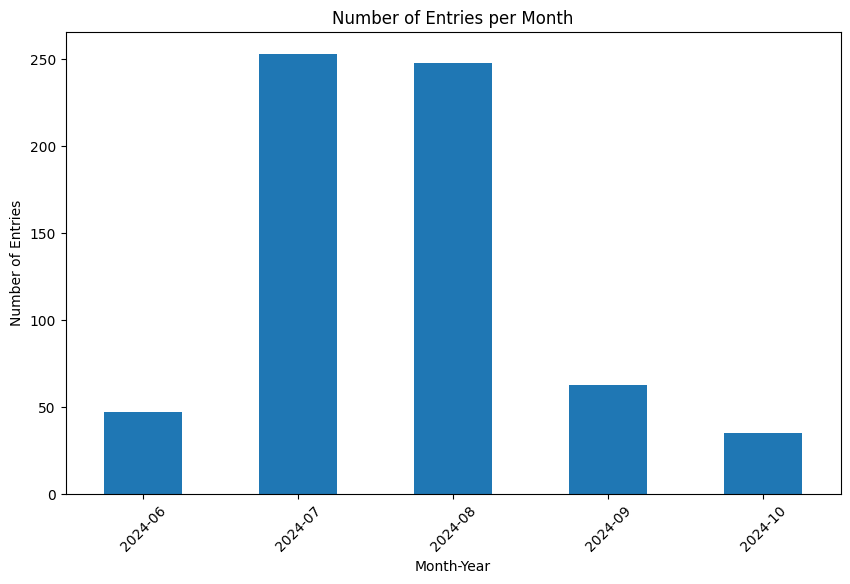

In [15]:
import matplotlib.pyplot as plt
# Count the number of entries in each month
monthly_counts = pd.to_datetime(df['Article Date']).dt.to_period('M').value_counts().sort_index()

# Plotting the bar chart
plt.figure(figsize=(10, 6))
monthly_counts.plot(kind='bar')
plt.xlabel('Month-Year')
plt.ylabel('Number of Entries')
plt.title('Number of Entries per Month')
plt.xticks(rotation=45)
plt.show()

In [8]:
from scripts.get_stock_advice import get_stock_price

await get_stock_price("TCS", "October 10, 2024", "CALL", 1000)

(4252.95,
 4149.2,
 'Call type not supported.',
 -76.48690908663399,
 -2.4394831822617244)